Import

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns

In [59]:
titanic_df = sns.load_dataset("titanic")

In [60]:
titanic_df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


#1

In [61]:
miss_vals = titanic_df.isnull()
miss_vals_number = miss_vals.sum()
print(miss_vals_number)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


#2

In [62]:
# View the duplicate rows
dupes = titanic_df[titanic_df.duplicated(keep=False)]
dupes.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True


In [63]:
# Drop dupes (keeps first instance)
titanic_df = titanic_df.drop_duplicates()

#3

In [64]:
# counting the values in sex column
titanic_df['sex'].value_counts(dropna=False)

sex
male      491
female    293
Name: count, dtype: int64

#4

In [65]:
# checking min and max of age to understand range
titanic_df['age'].min(), titanic_df['age'].max()

(0.42, 80.0)

In [66]:
# check age distribution
titanic_df['age'].describe()

count    678.000000
mean      29.869351
std       14.759076
min        0.420000
25%       20.000000
50%       28.250000
75%       39.000000
max       80.000000
Name: age, dtype: float64

In [67]:
# checking min and max of fare to understand range
titanic_df['fare'].min(), titanic_df['fare'].max()

(0.0, 512.3292)

In [68]:
# check fare distribution
titanic_df['fare'].describe()

count    784.000000
mean      34.711740
std       52.160151
min        0.000000
25%        8.050000
50%       15.900000
75%       34.109350
max      512.329200
Name: fare, dtype: float64

In [69]:
# calc the outliers of fare
Q1 = titanic_df['fare'].quantile(0.25)
Q3 = titanic_df['fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# view
outliers = titanic_df[
    (titanic_df['fare'] < lower_bound) | 
    (titanic_df['fare'] > upper_bound)
]

outliers

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,NaN,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False
61,1,1,female,38.0,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,1,1,female,62.0,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True
835,1,1,female,39.0,1,1,83.1583,C,First,woman,False,E,Cherbourg,yes,False
849,1,1,female,NaN,1,0,89.1042,C,First,woman,False,C,Cherbourg,yes,False
856,1,1,female,45.0,1,1,164.8667,S,First,woman,False,NaN,Southampton,yes,False


In [70]:
# drop fare outliers
titanic_df = titanic_df[
    (titanic_df['fare'] >= lower_bound) & 
    (titanic_df['fare'] <= upper_bound)
]

In [71]:
# sanity check of fare
titanic_df['fare'].describe()

count    682.000000
mean      19.507490
std       14.836515
min        0.000000
25%        7.895800
50%       13.000000
75%       26.550000
max       71.283300
Name: fare, dtype: float64

#5

In [72]:
# Create a family size col that adds the values in sibilings/spouses and parents/children cols
# added a 1 to include themselves as part of the family
titanic_df['family_size'] = titanic_df['sibsp'] + titanic_df['parch'] + 1
titanic_df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1


#6

In [73]:
#check the values in embarked
titanic_df['embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [74]:
#use mapping for files
mapping = {'S': 0, 'C': 1, 'Q': 2}
titanic_df['embarked_encoded'] = titanic_df['embarked'].map(mapping)
titanic_df[['embarked', 'embarked_encoded']].head()

,embarked,embarked_encoded
0,S,0
1,C,1
2,S,0
3,S,0
4,S,0


In [75]:
#change names of columns
titanic_df = titanic_df.drop(columns=['embarked'])
titanic_df = titanic_df.rename(columns={'embarked_encoded': 'embarked'})

#7-8 No relevant columns

#9

In [77]:
# Create bins and labels e.g 0-12 = Child
bins = [0, 12, 18, 60, 120]
labels = ['Child', 'Teen', 'Adult', 'Senior']

titanic_df['Age_Group'] = pd.cut(titanic_df['age'], bins=bins, labels=labels)

#View
titanic_df[['age', 'Age_Group']].head()

,age,Age_Group
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


In [79]:
#View count by age group
titanic_df['Age_Group'].value_counts()

Age_Group
Adult     444
Child      64
Teen       57
Senior     19
Name: count, dtype: int64

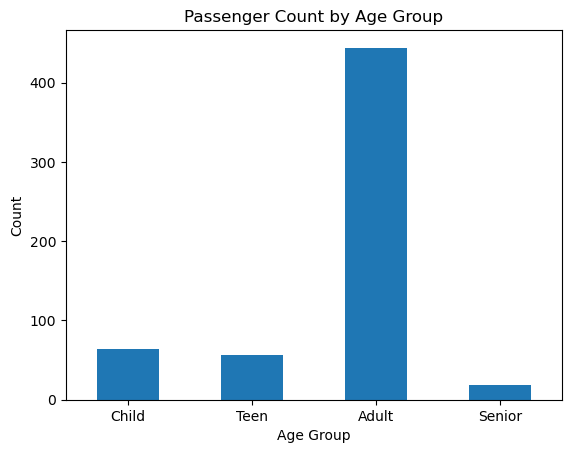

In [82]:
#view as diagram
order = ['Child', 'Teen', 'Adult', 'Senior']
titanic_df['Age_Group'] = pd.Categorical(titanic_df['Age_Group'], categories=order, ordered=True)

age_counts = titanic_df['Age_Group'].value_counts().reindex(order)

import matplotlib.pyplot as plt

age_counts.plot(kind='bar')

plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Passenger Count by Age Group')
plt.xticks(rotation=0)

plt.show()

1. take the df and drop any duplicates and NAs
2. take the df and make a table that contains any outliers and a table with no outliers from any numeric column

In [84]:
# reload titanic df
titanic_df = sns.load_dataset("titanic")

In [86]:
#1 Drop duplicate rows (keep the first), then drop any rows with NA values
titanic_df = titanic_df.drop_duplicates(keep='first').dropna()


In [87]:
#2.1 check numeric cols
numeric_cols = titanic_df.select_dtypes(include='number').columns
numeric_cols


Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')

In [89]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

# 2.2 Set IQR bounds for each numeric column
Q1 = titanic_df[numeric_cols].quantile(0.25)
Q3 = titanic_df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [90]:
#2.3 
# Boolean mask: True if row has ANY outlier in numeric columns
outlier_mask = ((titanic_df[numeric_cols] < lower_bound) | 
                (titanic_df[numeric_cols] > upper_bound)).any(axis=1)


In [93]:
#2.4 outliers table
outliers_df = titanic_df[outlier_mask]
outliers_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
10,1,3,female,4.0,1,1,16.70,S,Third,child,False,G,Southampton,yes,False
21,1,2,male,34.0,0,0,13.00,S,Second,man,True,D,Southampton,yes,True
27,0,1,male,19.0,3,2,263.00,S,First,man,True,C,Southampton,no,False
66,1,2,female,29.0,0,0,10.50,S,Second,woman,False,F,Southampton,yes,True
75,0,3,male,25.0,0,0,7.65,S,Third,man,True,F,Southampton,no,True


In [94]:
#2.5 no outliers table
no_outliers_df = titanic_df[~outlier_mask]
no_outliers_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
